<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-20 17:33:31--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  42.0MB/s    in 4.8s    

2026-01-20 17:33:38 (42.1 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 1.9 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 5.7 MB/s eta 0:00:000:00:01


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 30.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 33.5 MB/s eta 0:00:00ta 0:00:01


In [47]:
!pip install numpy

In [55]:
!pip install seaborn

In [56]:
import seaborn as sns

In [48]:
import numpy as np

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [43]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [31]:
# your code goes here

QUERY = """
SELECT CompTotal, COUNT(*) as count 
FROM main 
GROUP BY CompTotal
ORDER BY CompTotal
"""
df_CT = pd.read_sql_query(QUERY, conn)
#print(df_CT)

In [25]:
# 1. Clean Data: Remove NaN and zero/negative for log scaling
df_CT = df_CT.dropna(subset=['CompTotal'])
df_CT = df_CT[df_CT['CompTotal'] > 0].copy()

df_clean = df_CT[df_CT['CompTotal'] < 1e9] 

In [28]:
Q1 = df_CT['CompTotal'].quantile(0.25)
Q3 = df_CT['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe
df_clean = df_CT[(df_CT['CompTotal'] >= lower_bound) & (df_CT['CompTotal'] <= upper_bound)]

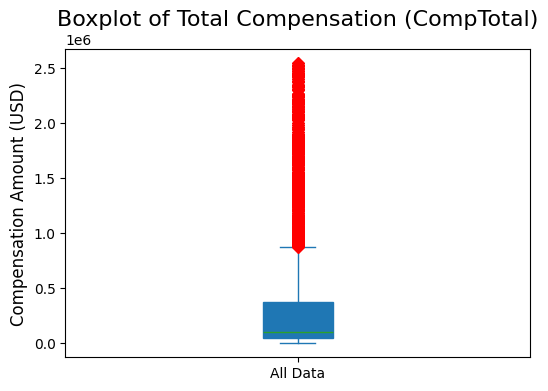

In [30]:
plt.figure(figsize=(6,4))
df_clean['CompTotal'].plot(kind='box', sym='rD', patch_artist=True)
plt.title('Boxplot of Total Compensation (CompTotal)', fontsize=16)
plt.ylabel('Compensation Amount (USD)', fontsize=12)
plt.xticks([1], ['All Data'])
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(df_clean, vert=True, patch_artist=True)
plt.yscale('log')

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [61]:
#df_age.head()

In [50]:
# Extract midpoints to represent the groups numerically
df_age['Age_numeric'] = df_age['Age'].str.findall(r'\d+').apply(lambda x: np.mean([int(i) for i in x]))

/opt/conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [53]:
# Repeat the numeric midpoints by their respective counts
age_data = np.repeat(df_age['Age_numeric'].values, df_age['count'].values)

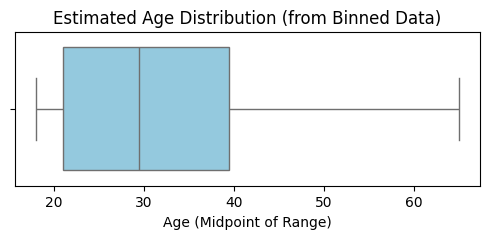

In [60]:
# Visualize using Seaborn
plt.figure(figsize=(6, 2))
sns.boxplot(x=age_data, color='skyblue')
plt.title('Estimated Age Distribution (from Binned Data)')
plt.xlabel('Age (Midpoint of Range)')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [67]:
# your code goes here
QUERY = """
SELECT 
    CASE 
        WHEN Age < 25 THEN '<25'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+' 
    END AS AgeGroup,
    CompTotal
FROM main
WHERE CompTotal IS NOT NULL 
  AND CompTotal > 0
  AND CompTotal < 1e9 
"""
df_Age_CT = pd.read_sql_query(QUERY, conn)
#print(df_Age_CT)

In [64]:
df_Age_CT['CompTotal'] = pd.to_numeric(df_Age_CT['CompTotal'], errors='coerce') # Ensure CompTotal is numeric
# Define the logical order for the AgeGroups
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

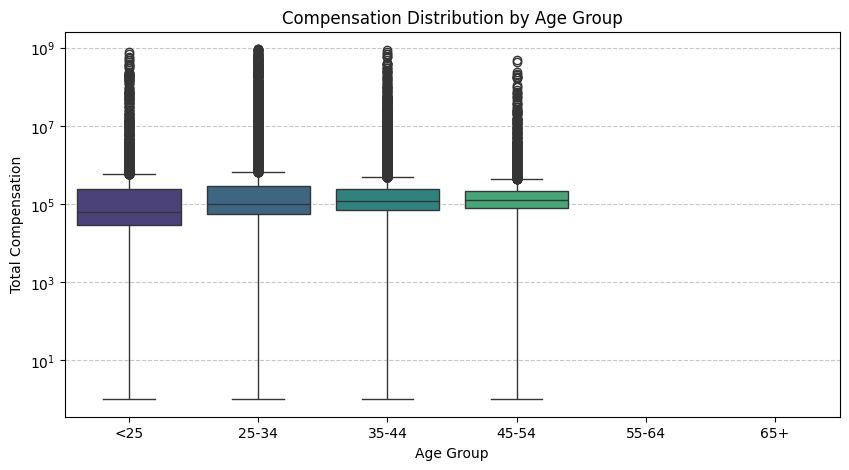

In [69]:
plt.figure(figsize=(10, 5))
# Use 'order' to ensure age groups appear chronologically, not alphabetically
sns.boxplot(data=df_Age_CT, x='AgeGroup', y='CompTotal', order=age_order, hue='AgeGroup', palette='viridis')
# Use a log scale if you have extreme salary differences (optional)
plt.yscale('log') 
plt.title('Compensation Distribution by Age Group')
plt.ylabel('Total Compensation')
plt.xlabel('Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [105]:
# your code goes here
QUERY = """
SELECT 
        JobSatPoints_6,
        CAST(CompTotal AS FLOAT) AS CompTotal -- Ensure numeric
    FROM Main
    WHERE CompTotal IS NOT NULL 
      AND JobSatPoints_6 IS NOT NULL
"""
df_JBSat_CT = pd.read_sql_query(QUERY, conn)
#print(df_JBSat_CT)

In [96]:
# Ensure CompTotal and JobSatPoints_6 are numeric
df_JBSat_CT['CompTotal'] = pd.to_numeric(df_JBSat_CT['CompTotal'], errors='coerce')
# Round and convert to integer
df_JBSat_CT['JobSatPoints_6'] = df_JBSat_CT['JobSatPoints_6'].round(-1).astype(int)

In [97]:
Q1 = df_JBSat_CT['CompTotal'].quantile(0.25)
Q3 = df_JBSat_CT['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe
df_clean = df_JBSat_CT[(df_JBSat_CT['CompTotal'] >= lower_bound) & (df_JBSat_CT['CompTotal'] <= upper_bound)]

In [98]:
# Drop missing values for these specific columns to clean the plot
df_clean = df_clean.dropna(subset=['CompTotal', 'JobSatPoints_6'])

In [104]:
#df_clean['JobSatPoints_6'].value_counts()

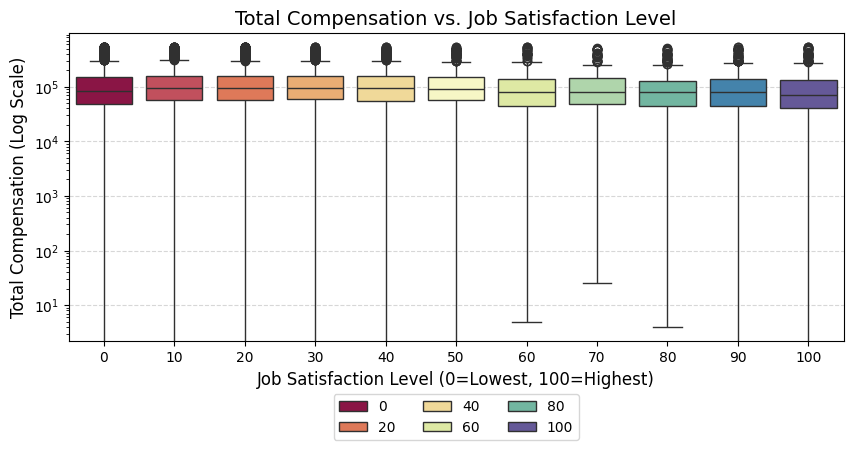

In [103]:
plt.figure(figsize=(10, 4))
# Plotting CompTotal grouped by JobSatPoints_6
sns.boxplot(data=df_clean, x='JobSatPoints_6', y='CompTotal', hue='JobSatPoints_6', palette='Spectral')
# Handle extreme salary outliers by using a log scale (highly recommended for compensation data)
plt.yscale('log')
# Labeling and styling
plt.title('Total Compensation vs. Job Satisfaction Level', fontsize=14)
plt.xlabel('Job Satisfaction Level (0=Lowest, 100=Highest)', fontsize=12)
plt.ylabel('Total Compensation (Log Scale)', fontsize=12)
# Move legend to the lower center, outside the plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [121]:
# your code goes here
QUERY = """
WITH Top5Devs AS (
    SELECT DevType
    FROM Main
    WHERE DevType IS NOT NULL
    GROUP BY DevType
    ORDER BY COUNT(DevType) DESC
    LIMIT 5
)
SELECT DevType, ConvertedCompYearly
FROM Main
WHERE DevType IN (SELECT DevType FROM Top5Devs)
  AND ConvertedCompYearly IS NOT NULL;
"""
df_DevTy_CCYR = pd.read_sql_query(QUERY, conn)
#print(df_DevTy_CCYR)

In [117]:
# 1. Identify the top 5 most frequent DevTypes
top_5_roles = df_DevTy_CCYR['DevType'].value_counts().head(5).index.tolist()

In [118]:
# 2. Filter the original dataframe for only these roles
df_top_5 = df_DevTy_CCYR[df_DevTy_CCYR['DevType'].isin(top_5_roles)]

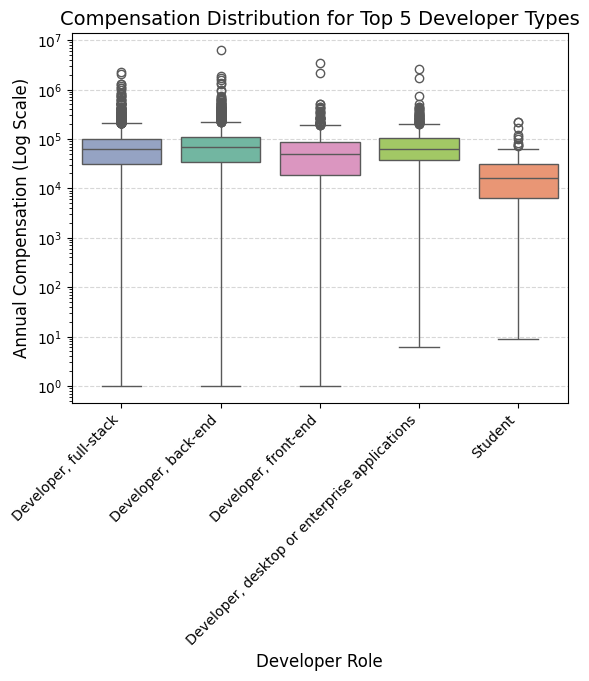

In [122]:
# Plot the boxplot
sns.boxplot(
    data=df_top_5, 
    x='DevType', 
    y='ConvertedCompYearly',
    hue='DevType',
    order=top_5_roles, # Maintains descending order by frequency
    palette='Set2',
    legend=False
)
# Apply log scale for 2026 salary variance
plt.yscale('log')
# Formatting for clarity
plt.title('Compensation Distribution for Top 5 Developer Types', fontsize=14)
plt.ylabel('Annual Compensation (Log Scale)', fontsize=12)
plt.xlabel('Developer Role', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate long labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [136]:
# your code goes here
QUERY = """
WITH Top5Countries AS (
    SELECT Country
    FROM Main
    WHERE Country IS NOT NULL
    GROUP BY Country
    ORDER BY COUNT(Country) DESC
    LIMIT 5
)
SELECT Country, CompTotal
FROM Main
WHERE Country IN (SELECT Country FROM Top5Countries)
  AND CompTotal IS NOT NULL;
"""
df_Country_CT = pd.read_sql_query(QUERY, conn)
#print(df_Country_CT)

In [133]:
# 1. Identify the top 5 most frequent Country
top_5_Countries = df_Country_CT['Country'].value_counts().head(5).index.tolist()
print(top_5_Countries)

['United States of America', 'Germany', 'United Kingdom of Great Britain and Northern Ireland', 'Ukraine', 'India']


In [137]:
# 2. Filter the original dataframe for only these roles
df_top_5_C = df_Country_CT[df_Country_CT['Country'].isin(top_5_Countries)]
#df_top_5_C.head()

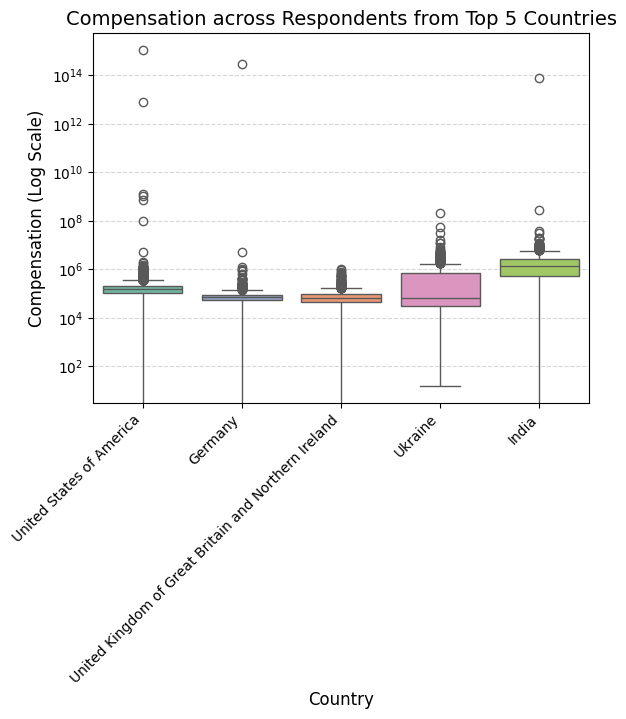

In [135]:
# Plot the boxplot
sns.boxplot(
    data=df_top_5_C, 
    x='Country', 
    y='CompTotal',
    hue='Country',
    order=top_5_Countries, # Maintains descending order by frequency
    palette='Set2',
    legend=False
)
# Apply log scale for 2026 salary variance
plt.yscale('log')
# Formatting for clarity
plt.title('Compensation across Respondents from Top 5 Countries', fontsize=14)
plt.ylabel('Compensation (Log Scale)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate long labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [203]:
# your code goes here
QUERY = """
SELECT 
        Employment,
        CAST(CompTotal AS FLOAT) AS CompTotal -- Ensure numeric for 2026 calculations
    FROM Main
    WHERE CompTotal IS NOT NULL 
      AND Employment IS NOT NULL
"""
df_Emp_CT = pd.read_sql_query(QUERY, conn)
#print(df_Emp_CT)

In [204]:
# Ensure CompTotal is numeric
df_Emp_CT['CompTotal'] = pd.to_numeric(df_Emp_CT['CompTotal'], errors='coerce')

In [205]:
# Keep data between the 1st and 99th percentile
lower_limit = df_Emp_CT['CompTotal'].quantile(0.01)
upper_limit = df_Emp_CT['CompTotal'].quantile(0.99)

df_Emp_CT = df_Emp_CT[(df_Emp_CT['CompTotal'] > lower_limit) & (df_Emp_CT['CompTotal'] < upper_limit)]


Q1 = df_Emp_CT['CompTotal'].quantile(0.25)
Q3 = df_Emp_CT['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe
df_Emp_CT = df_Emp_CT[(df_Emp_CT['CompTotal'] >= lower_bound) & (df_Emp_CT['CompTotal'] <= upper_bound)]

In [206]:
# 1. Split the strings by semicolon into lists
df_Emp_CT['Employment'] = df_Emp_CT['Employment'].str.split(';')

In [207]:
df_clean = df_Emp_CT.explode('Employment')

In [208]:
# 3. Standardize text (remove whitespace and standardize casing)
df_clean['Employment'] = df_clean['Employment'].str.strip().str.capitalize()

In [209]:
mapping = {
    'Employed, Full-Time': 'Full-time',
    'Employed, Part-Time': 'Part-time',
    'Independent contractor, freelancer, or self-employed': 'Contractor',
    'Not Employed, But Looking For Work': 'Unemployed',
    'Not employed, and not looking for work': 'Other',
    'Not employed, but looking for work': 'Look for Work',
    'Retired' : 'Retired'
}

# Replace specific substrings or exact matches
df_clean['Employment'] = df_clean['Employment'].replace(mapping, regex=True)

In [215]:
#df_clean['Employment'].value_counts()

In [211]:
# Drop missing values for these specific columns to clean the plot
df_clean = df_clean.dropna(subset=['Employment', 'CompTotal'])

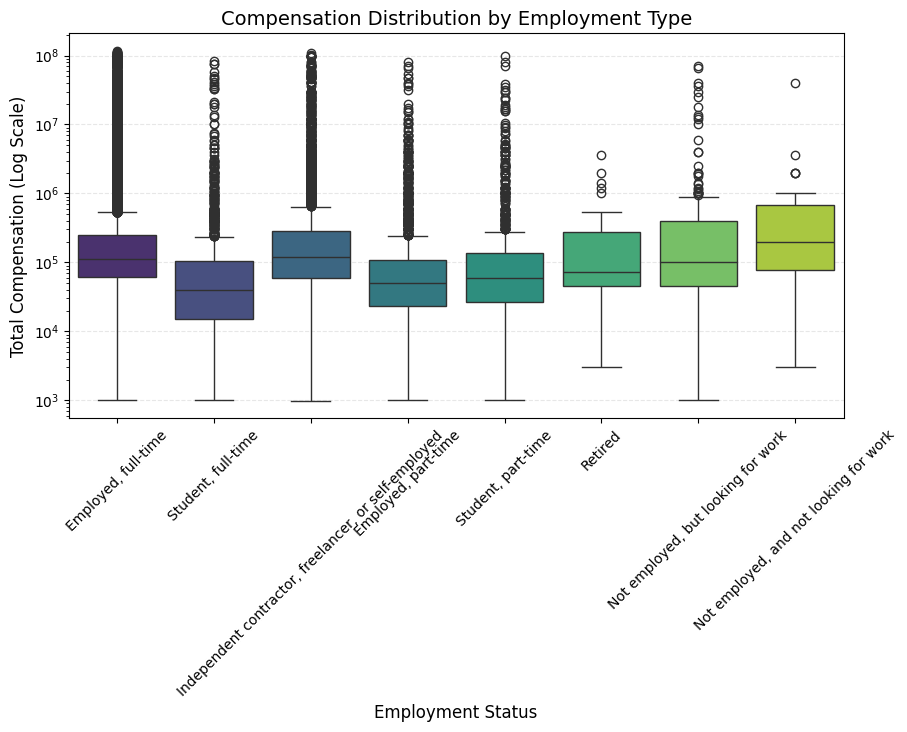

In [216]:
# 1. Prepare Figure
plt.figure(figsize=(10,5))
# 2. Create Boxplot
# 'Employment' on x-axis (categorical), 'CompTotal' on y-axis (numeric)
sns.boxplot(data=df_clean, x='Employment', y='CompTotal', hue='Employment', palette='viridis', legend=False)
# 3. Apply Log Scale (Essential for salary distribution in 2026)
plt.yscale('log')
# 4. Refine Aesthetics
plt.title('Compensation Distribution by Employment Type', fontsize=14)
plt.xlabel('Employment Status', fontsize=12)
plt.ylabel('Total Compensation (Log Scale)', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [224]:
# your code goes here
QUERY = """
SELECT 
        -- Cast to float to ensure numeric handling for coding years
        CAST(YearsCodePro AS FLOAT) AS ExperienceYears,
        JobSatPoints_6
    FROM Main
    WHERE YearsCodePro IS NOT NULL 
      AND JobSatPoints_6 IS NOT NULL
"""
df_Exp_JbSat = pd.read_sql_query(QUERY, conn)
#print(df_Exp_JbSat)

In [219]:
# Ensure CompTotal is numeric
df_Exp_JbSat['ExperienceYears'] = pd.to_numeric(df_Exp_JbSat['ExperienceYears'], errors='coerce')
df_Exp_JbSat['JobSatPoints_6'] = pd.to_numeric(df_Exp_JbSat['JobSatPoints_6'], errors='coerce')

In [220]:
# Drop missing values for these specific columns to clean the plot
df_Exp_JbSat = df_Exp_JbSat.dropna(subset=['ExperienceYears', 'JobSatPoints_6'])

In [222]:
# Define bin edges and descriptive labels
# [0-2] Entry, [2-5] Junior, [5-10] Mid, [10-20] Senior, [20+] Expert
bins = [-1, 2, 5, 10, 20, 100]
labels = ['Entry-level (0-2)', 'Junior (2-5)', 'Mid-level (5-10)', 'Senior (10-20)', 'Expert (20+)']

# Create the new grouping column
df_Exp_JbSat['ExperienceYears'] = pd.cut(df_Exp_JbSat['ExperienceYears'], bins=bins, labels=labels)

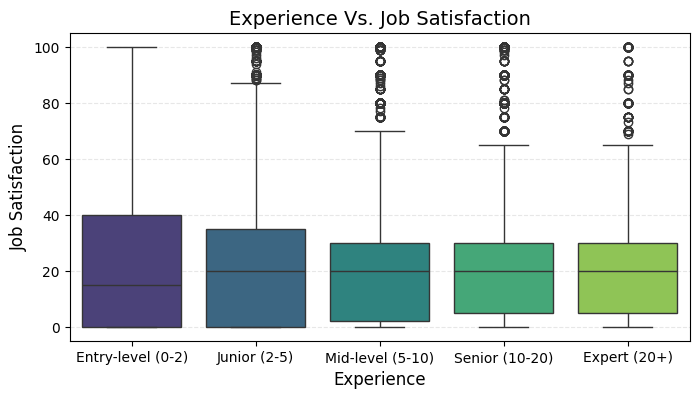

In [223]:
# 1. Prepare Figure
plt.figure(figsize=(8,4))
# 2. Create Boxplot
# 'Employment' on x-axis (categorical), 'CompTotal' on y-axis (numeric)
sns.boxplot(data=df_Exp_JbSat, x='ExperienceYears', y='JobSatPoints_6', hue='ExperienceYears', palette='viridis', legend=False)
# 3. Apply Log Scale (Essential for salary distribution in 2026)
#plt.yscale('log')
# 4. Refine Aesthetics
plt.title('Experience Vs. Job Satisfaction', fontsize=14)
plt.xlabel('Experience', fontsize=12)
plt.ylabel('Job Satisfaction', fontsize=12)
#plt.xticks(rotation=45) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
